# 📚 Chapter 2: Tokens and Embeddings

---

## 📋 Table of Contents

1. [Introduction to Tokens & Embeddings](#1-introduction-to-tokens--embeddings)
2. [LLM Tokenization Fundamentals](#2-llm-tokenization-fundamentals)
3. [How Tokenizers Work](#3-how-tokenizers-work)
4. [Types of Tokenization](#4-types-of-tokenization)
5. [Comparing Tokenizers](#5-comparing-tokenizers)
6. [Token Embeddings](#6-token-embeddings)
7. [Contextualized Word Embeddings](#7-contextualized-word-embeddings)
8. [Text Embeddings](#8-text-embeddings)
9. [Word2Vec & Recommendation Systems](#9-word2vec--recommendation-systems)
10. [Interview Questions](#10-interview-questions)
11. [Mind Maps](#11-mind-maps)

---

## 1. Introduction to Tokens & Embeddings


### 🎯 Core Concepts

Tokens and embeddings are the two most central concepts for understanding how Large Language Models (LLMs) function. Language models cannot read text mathematically; instead, they rely on a two-step transformation:



1.  **Tokenization:** Breaking down the input text into smaller, manageable pieces (words, subwords, or characters).

2.  **Embedding:** Turning those individual tokens into numeric representations (high-dimensional vectors) that capture their semantic meaning.



When you chat with an LLM, it doesn't generate the response all at once. It processes the prompt as a list of Token IDs and predicts/generates the response exactly one token at a time.


### 🔑 Key Insights

```
┌───────────────────────────────────────────────────────────────┐
│                    LLM Processing Pipeline                    │
├───────────────────────────────────────────────────────────────┤
│                                                               │
│  Raw Text → Tokenizer → Token IDs → Embeddings → LLM → Output │
│                                                               │
│  "Hello world" → ["Hello", "world"] → [15496, 995] → [vectors]│
│                                                               │
└───────────────────────────────────────────────────────────────┘
```

**Critical Understanding:**
- LLMs don't "read" text like humans do
- They see sequences of numbers (token IDs)
- Each token ID maps to an embedding vector in high-dimensional space
- These embeddings capture semantic relationships (e.g., "king" - "man" + "woman" ≈ "queen")

### 📊 Why This Matters

1. **Model Generation**: LLMs generate one token at a time, not entire responses at once
2. **Performance**: Tokenization affects speed, efficiency, and model capabilities
3. **Multilingual Support**: Different tokenizers handle languages, code, and special characters differently

---

## 2. LLM Tokenization Fundamentals


### 🔄 The Tokenization Process

When you interact with an LLM:

1. **Input Processing**: Your text prompt → broken into tokens → converted to numeric IDs
2. **Model Processing**: The LLM processes these token IDs through its neural network
3. **Output Processing**: Output token IDs → converted back to human-readable text

### 💡 Why Tokenization is Critical

- **Context Window**: Subword tokenization allows ~3x more text in the same context length vs character tokens
- **Efficiency**: Better tokenizers = fewer tokens = faster inference & lower costs
- **Capabilities**: Specialized tokenizers improve performance on code, math, or multilingual tasks


In [37]:
# Install dependencies (run once)
# !pip install -q transformers accelerate torch

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

print("="*70)
print("STEP 1: LOAD MODEL AND TOKENIZER")
print("="*70)

# Modern instruction-tuned model
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

# Load model with optimizations
# FIX 1: Changed torch_dtype to torch.bfloat16 to prevent Out-Of-Memory (OOM) errors in Colab.
# "auto" sometimes defaults to float32, which requires double the VRAM.
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",           # Auto-detect GPU/CPU
    torch_dtype=torch.bfloat16,  # Recommended precision for Qwen2.5
    trust_remote_code=True
)

print(f"✓ Model: {MODEL_NAME}")
print(f"✓ Device: {model.device}")
print(f"✓ Vocabulary Size: {len(tokenizer):,} tokens")

# FIX 2: Qwen models use 'hidden_size' instead of 'n_embd' in their config.
# Accessing n_embd throws an AttributeError.
print(f"✓ Model Hidden Size: {model.config.hidden_size} dimensions")



STEP 1: LOAD MODEL AND TOKENIZER


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

✓ Model: Qwen/Qwen2.5-3B-Instruct
✓ Device: cuda:0
✓ Vocabulary Size: 151,665 tokens
✓ Model Hidden Size: 2048 dimensions


In [2]:
print("\n" + "="*70)
print("STEP 2: PREPARE PROMPT WITH CHAT TEMPLATE")
print("="*70)

# Modern chat format (required for instruction-tuned models)
messages = [
    {
        "role": "user",
        "content": "Write a 2-sentence apology email to Sarah for a tragic gardening mishap."
    }
]

# Apply chat template (adds special tokens automatically)
text_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

print(f"Formatted Prompt:\n{text_prompt}\n")


STEP 2: PREPARE PROMPT WITH CHAT TEMPLATE
Formatted Prompt:
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Write a 2-sentence apology email to Sarah for a tragic gardening mishap.<|im_end|>
<|im_start|>assistant




In [3]:
print("="*70)
print("STEP 3: TOKENIZE AND GENERATE")
print("="*70)

# Tokenize
inputs = tokenizer(text_prompt, return_tensors="pt").to(model.device)

print(f"Number of Input Tokens: {len(inputs['input_ids'][0])}")

# FIX 3: Safely determine the pad_token_id to prevent generation warnings/errors.
# Qwen2 often uses the eos_token_id for padding.
pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

# Generate response
outputs = model.generate(
    **inputs,
    max_new_tokens=100,       # Increased slightly to ensure the 2-sentence email finishes
    do_sample=True,           # Add randomness for better quality
    temperature=0.7,          # Balance creativity (0=deterministic, 1=creative)
    pad_token_id=pad_token_id
)

# FIX 4: Decode ONLY the newly generated tokens.
# If you decode outputs[0] directly, it will print your prompt + the response.
generated_tokens = outputs[0][inputs['input_ids'].shape[1]:]
response = tokenizer.decode(generated_tokens, skip_special_tokens=True)

print("\n" + "="*70)
print("GENERATED RESPONSE")
print("="*70)
print(response)

STEP 3: TOKENIZE AND GENERATE
Number of Input Tokens: 46

GENERATED RESPONSE
Dear Sarah, I am truly sorry for the accident that occurred in your garden. We deeply regret any inconvenience or harm caused and hope you can forgive us. Please let us know how we can make it right.


### 🔍 Understanding the Output

When you run the code above, observe:

1. **Token IDs**: Each word/subword maps to a unique integer from the vocabulary
2. **Special Tokens**: The chat template adds tokens like `<|im_start|>` and `<|im_end|>`
3. **Generation**: The model predicts one token at a time until it reaches max_new_tokens or an end token

---

## 3. How Tokenizers Work

**Text Cell - Markdown**

### 🧩 Tokenizer Anatomy

A tokenizer performs two critical functions:

1. **Encoding**: Text → Token IDs
2. **Decoding**: Token IDs → Text

### 📐 Tokenizer Design Decisions

Three major factors determine how a tokenizer behaves:

**1. Tokenization Method**
- **Byte Pair Encoding (BPE)**: Used by GPT-2, GPT-4, Llama 2
- **WordPiece**: Used by BERT
- **SentencePiece**: Used by T5, supports multiple methods
- **Unigram**: Alternative subword method

**2. Parameters**
- Vocabulary size (30K, 50K, 100K+ tokens)
- Special tokens (`<s>`, `</s>`, `<pad>`, `<unk>`, etc.)
- Case handling (cased vs uncased)

**3. Training Data**
- Tokenizers trained on code handle indentation better
- Multilingual tokenizers support more languages
- Domain-specific tokenizers (science, law, medicine) optimize for their field



In [4]:
# ============================================================
# INSPECTING TOKENIZATION IN DETAIL
# ============================================================

from transformers import AutoTokenizer

print("="*70)
print("TOKENIZER INSPECTION TOOL")
print("="*70)

# Load Phi-3 tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    trust_remote_code=True
)

# Test text
text = "Write an email apologizing to Sheetal for the tragic gardening mishap."

print(f"\nOriginal Text:\n{text}\n")

# Tokenize
tokens = tokenizer(text, return_tensors="pt")
token_ids = tokens['input_ids'][0]

print("="*70)
print("TOKEN BREAKDOWN")
print("="*70)
print(f"{'Position':<10} {'Token ID':<12} {'Token Text':<20}")
print("-"*70)

for i, token_id in enumerate(token_ids):
    token_text = tokenizer.decode(token_id)
    # Show special characters visibly
    token_display = token_text.replace(' ', '·')
    print(f"{i:<10} {token_id.item():<12} '{token_display}'")

TOKENIZER INSPECTION TOOL


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

configuration_phi3.py:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-4k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]


Original Text:
Write an email apologizing to Sheetal for the tragic gardening mishap.

TOKEN BREAKDOWN
Position   Token ID     Token Text          
----------------------------------------------------------------------
0          14350        'Write'
1          385          'an'
2          4876         'email'
3          27746        'apolog'
4          5281         'izing'
5          304          'to'
6          2296         'She'
7          26310        'etal'
8          363          'for'
9          278          'the'
10         25305        'trag'
11         293          'ic'
12         16423        'garden'
13         292          'ing'
14         286          'm'
15         728          'ish'
16         481          'ap'
17         29889        '.'


In [5]:
print("\n" + "="*70)
print("OBSERVATIONS")
print("="*70)

# Analyze tokenization patterns
print("1. Special Tokens:")
print(f"   - First token: {tokenizer.decode(token_ids[0])} (start of text)")
print(f"   - Last token: {tokenizer.decode(token_ids[-1])} (end of text)")


OBSERVATIONS
1. Special Tokens:
   - First token: Write (start of text)
   - Last token: . (end of text)


In [6]:
print("\n2. Subword Tokenization:")
print("   - 'apologizing' → 'apolog' + 'izing'")
print("   - 'gardening' → 'garden' + 'ing'")
print("   - 'tragic' → 'trag' + 'ic'")


2. Subword Tokenization:
   - 'apologizing' → 'apolog' + 'izing'
   - 'gardening' → 'garden' + 'ing'
   - 'tragic' → 'trag' + 'ic'


In [7]:
print("\n3. Punctuation:")
print("   - Each punctuation mark is its own token")


3. Punctuation:
   - Each punctuation mark is its own token


In [8]:
print("\n4. Spaces:")
print("   - Spaces are implicit (tokens without prefix have space before)")
print("   - Partial tokens use special character to indicate continuation")


4. Spaces:
   - Spaces are implicit (tokens without prefix have space before)
   - Partial tokens use special character to indicate continuation


In [9]:
# Show vocabulary info
print("\n" + "="*70)
print("VOCABULARY STATISTICS")
print("="*70)
print(f"Total Vocabulary Size: {len(tokenizer):,} tokens")
print(f"Unique Tokens in This Text: {len(set(token_ids.tolist()))}")
print(f"Average Characters per Token: {len(text)/len(token_ids):.2f}")


VOCABULARY STATISTICS
Total Vocabulary Size: 32,011 tokens
Unique Tokens in This Text: 18
Average Characters per Token: 3.89


### 🎨 Visual Tokenization Example

```
Text: "apologizing"

Tokenization Process:
┌─────────────┐
│ apologizing │  Original word
└─────────────┘
        ↓
┌───────────────┐
│ apolog + izing│  Split into subwords
└───────────────┘
        ↓
┌───────────────┐
│ 27746 + 5281  │  Token IDs
└───────────────┘
        ↓
┌─────────────────────┐
│ [vector₁, vector₂]  │  Embedding vectors
└─────────────────────┘
```

---

## 4. Types of Tokenization

### 📊 Four Main Tokenization Schemes

The creator of an LLM must choose a tokenization scheme before training. There are four notable ways to tokenize text:

1. **Word Tokens**: Breaks text by spaces. Problem: Fails when encountering new words and creates bloated vocabularies (e.g., treating "apologize", "apology", and "apologetic" as completely unrelated tokens).

2. **Subword Tokens** (Most Popular): Breaks words into smaller, reusable chunks. "apologetic" becomes `apolog` + `etic`. This allows models to reconstruct completely new words from known syllables.

3. **Character Tokens**: Breaks text down to raw letters `[a, p, o, l, o, ...]`. Problem: Takes up way too much space in the model's context window because it requires 3x more tokens to say the same thing.

4. **Byte Tokens**: Breaks text into individual bytes used for unicode characters. Useful as a fallback or for highly multilingual scenarios (like the ByT5 model).



| Method | Example | Pros | Cons | Best For |
|--------|---------|------|------|----------|
| **Word** | `["Playing", "tennis"]` | Simple, intuitive | Can't handle new words, huge vocabulary | Early NLP, simple tasks |
| **Subword** | `["Play", "ing", "ten", "nis"]` | Handles new words, efficient vocab | More complex | **Modern LLMs** (GPT, BERT, Llama) |
| **Character** | `["P", "l", "a", "y", "i", "n", "g"]` | Smallest vocab, handles everything | Very long sequences | Specialized applications |
| **Byte** | `[80, 108, 97, 121, 105, 110, 103]` | Universal, no vocab limits | Longest sequences | Multilingual, tokenization-free models |

### 🔬 Deep Dive: Subword Tokenization

**Why Subword Dominates:**

1. **Vocabulary Efficiency**: ~30K-100K tokens vs millions for word-level
2. **New Word Handling**: "ChatGPT" → "Chat" + "G" + "PT" (all known tokens)
3. **Context Length**: 3x more text fits in the same context window vs character tokens
4. **Cross-lingual**: Shares subwords across languages (e.g., "tion" in English/French)


In [10]:
# ============================================================
# COMPARING TOKENIZATION METHODS
# ============================================================

from transformers import AutoTokenizer
import pandas as pd

print("="*70)
print("TOKENIZATION METHOD COMPARISON")
print("="*70)

# Test texts covering different scenarios
test_texts = {
    "Simple English": "The quick brown fox jumps over the lazy dog.",
    "Code": "def add_numbers(a, b):\n    return a + b",
    "Mixed Case": "iPhone, eBay, and NASA are proper nouns.",
    "Numbers & Math": "Calculate 12.5 * 50 = 625.0",
    "Special Chars": "Email: user@domain.com, URL: https://example.com",
    "Emoji & Unicode": "Hello 🌍! Café naïve résumé"
}

# Tokenizers to compare
tokenizers_to_test = [
    ("BERT (WordPiece)", "bert-base-uncased"),
    ("GPT-2 (BPE)", "gpt2"),
    ("Phi-3 (BPE + Chat)", "microsoft/Phi-3-mini-4k-instruct"),
]

results = []

for name, model_path in tokenizers_to_test:
    print(f"\n{'='*70}")
    print(f"TOKENIZER: {name}")
    print(f"{'='*70}")

    try:
        tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)

        for text_name, text in test_texts.items():
            tokens = tokenizer(text, return_tensors="pt")
            num_tokens = len(tokens.input_ids[0])
            num_chars = len(text)

            results.append({
                'Tokenizer': name,
                'Text Type': text_name,
                'Tokens': num_tokens,
                'Chars': num_chars,
                'Chars/Token': f"{num_chars/num_tokens:.2f}"
            })

        print(f"✓ Loaded successfully")
        print(f"  Vocabulary: {len(tokenizer):,} tokens")

    except Exception as e:
        print(f"✗ Error: {e}")

TOKENIZATION METHOD COMPARISON

TOKENIZER: BERT (WordPiece)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

✓ Loaded successfully
  Vocabulary: 50,257 tokens

TOKENIZER: Phi-3 (BPE + Chat)
✓ Loaded successfully
  Vocabulary: 32,011 tokens


In [11]:
# Create comparison table
df = pd.DataFrame(results)
print("\n" + "="*70)
print("COMPARISON TABLE")
print("="*70)
print(df.to_string(index=False))


COMPARISON TABLE
         Tokenizer       Text Type  Tokens  Chars Chars/Token
  BERT (WordPiece)  Simple English      12     44        3.67
  BERT (WordPiece)            Code      16     39        2.44
  BERT (WordPiece)      Mixed Case      13     40        3.08
  BERT (WordPiece)  Numbers & Math      12     27        2.25
  BERT (WordPiece)   Special Chars      20     48        2.40
  BERT (WordPiece) Emoji & Unicode       8     26        3.25
       GPT-2 (BPE)  Simple English      10     44        4.40
       GPT-2 (BPE)            Code      18     39        2.17
       GPT-2 (BPE)      Mixed Case      11     40        3.64
       GPT-2 (BPE)  Numbers & Math      12     27        2.25
       GPT-2 (BPE)   Special Chars      15     48        3.20
       GPT-2 (BPE) Emoji & Unicode      10     26        2.60
Phi-3 (BPE + Chat)  Simple English      12     44        3.67
Phi-3 (BPE + Chat)            Code      15     39        2.60
Phi-3 (BPE + Chat)      Mixed Case      14     40   

In [12]:
# Analysis
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print("1. Chars/Token ratio indicates efficiency:")
print("   - Higher = more efficient (more text per token)")
print("   - Subword tokenizers typically achieve 3-4 chars/token")
print("   - Character tokenizers = 1 char/token")
print("\n2. Code Handling:")
print("   - Code-focused tokenizers preserve whitespace/indentation")
print("   - General tokenizers may split code keywords inefficiently")



KEY INSIGHTS
1. Chars/Token ratio indicates efficiency:
   - Higher = more efficient (more text per token)
   - Subword tokenizers typically achieve 3-4 chars/token
   - Character tokenizers = 1 char/token

2. Code Handling:
   - Code-focused tokenizers preserve whitespace/indentation
   - General tokenizers may split code keywords inefficiently


### 🎯 When to Use Each Method

**Word Tokenization:**
- ✅ Simple classification tasks
- ✅ Small, controlled vocabularies
- ❌ **Avoid for**: Modern LLMs, multilingual applications

**Subword Tokenization:**
- ✅ **Default choice** for most LLM applications
- ✅ Code generation, multilingual tasks
- ✅ When you need to handle new words

**Character Tokenization:**
- ✅ Spelling correction
- ✅ Morphologically rich languages
- ❌ **Avoid for**: General text (too inefficient)

**Byte Tokenization:**
- ✅ Tokenization-free models (ByT5, CANINE)
- ✅ Extreme multilingual scenarios
- ❌ **Avoid for**: Standard applications (computationally expensive)

---

## 5. Comparing Tokenizers

**Text Cell - Markdown**

### 🏆 Real-World Tokenizer Comparison

Different models use specialized tokenizers optimized for their specific domains:

| Model | Method | Vocab Size | Special Features | Strengths |
|-------|--------|------------|------------------|-----------|
| **BERT (uncased)** | WordPiece | 30,522 | `[CLS]`, `[SEP]`, `[MASK]` | Converts everything to lowercase, destroys newlines, and uses special tokens like `[CLS]` (Classification) and `[SEP]` (Separator) |
| **BERT (cased)** | WordPiece | 28,996 | Preserves case | Case-sensitive tasks |
| **GPT-2** | BPE | 50,257 | `<\|endoftext\|>` | General text generation |
| **GPT-4** | BPE | 100,000+ | Whitespace tokens (1-83 spaces), FIM tokens |Preserves capitalization and newlines. GPT-4 has specialized tokens for different amounts of whitespace (up to 83 spaces), which drastically improves coding capabilities.  |
| **StarCoder2** | BPE | 49,152 | Digit-by-digit, `<filename>`, `<reponame>` |  Highly optimized for code. It treats individual digits as separate tokens (e.g., `600` is parsed as `6`, `0`, `0`) to prevent the model from getting confused during mathematical operations.  |
| **Galactica** | BPE | 50,000 | `[START_REF]`, `<work>`, DNA tokens | Optimized for science. Contains specialized tokens for citations `[START_REF]`, reasoning `<work>`, and even DNA/amino acid sequences. |
| **Phi-3/Llama 2** | BPE | 32,000 | `<\|user\|>`, `<\|assistant\|>` | Includes specialized "Chat Tokens" like `<\|user\|>` and `<\|assistant\|>` to separate conversation turns between a human and the AI. |

### 🔍 Special Token Features

**GPT-4's Whitespace Optimization:**
- Has dedicated tokens for 1 space, 2 spaces, 3 spaces... up to 83 consecutive spaces
- Critical for Python code (indentation matters!)
- Example: `"\t\t"` (two tabs) = 1 token instead of 2

**StarCoder2's Digit Handling:**
- Treats each digit as a separate token: `600` → `6`, `0`, `0`
- Prevents confusion: `870` and `871` aren't treated as similar just because they share "87"
- Better for mathematical reasoning

**Galactica's Scientific Tokens:**
- `[START_REF]` and `[END_REF]` for citations
- `<work>` for chain-of-thought reasoning
- Special tokens for amino acid sequences and DNA


In [13]:
# ============================================================
# SPECIALIZED TOKENIZER COMPARISON
# Code vs General vs Scientific
# ============================================================

from transformers import AutoTokenizer

print("="*70)
print("SPECIALIZED TOKENIZER ANALYSIS")
print("="*70)

# Test cases for different domains
test_cases = {
    "Python Code": """
def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n-1) + fibonacci(n-2)
""",
    "Math Expression": "Calculate: 12.5 * 50 + 100 = 725.0",
    "Scientific Text": "The mitochondria [START_REF]Smith et al., 2020[END_REF] produces ATP.",
    "Chat Format": "<|user|>Hello!<|end|><|assistant|>Hi there!<|end|>"
}

# Specialized tokenizers
tokenizers = {
    "General (GPT-2)": "gpt2",
    "Code (StarCoder2)": "bigcode/starcoder2-base-3b",
    "Chat (Phi-3)": "microsoft/Phi-3-mini-4k-instruct",
}

for text_name, text in test_cases.items():
    print(f"\n{'='*70}")
    print(f"TEST CASE: {text_name}")
    print(f"{'='*70}")
    print(f"Text: {text[:80]}...")
    print()

    for tokenizer_name, model_path in tokenizers.items():
        try:
            tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
            tokens = tokenizer(text, return_tensors="pt")
            num_tokens = len(tokens.input_ids[0])

            # Show first 10 tokens
            first_tokens = [tokenizer.decode(tid) for tid in tokens.input_ids[0][:10]]

            print(f"{tokenizer_name:<25} | Tokens: {num_tokens:3d} | First tokens: {first_tokens[:5]}")

        except Exception as e:
            print(f"{tokenizer_name:<25} | Error: {str(e)[:50]}")



SPECIALIZED TOKENIZER ANALYSIS

TEST CASE: Python Code
Text: 
def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n-1) + f...

General (GPT-2)           | Tokens:  50 | First tokens: ['\n', 'def', ' fib', 'on', 'acci']
Code (StarCoder2)         | Error: bigcode/starcoder2-base-3b is not a local folder a
Chat (Phi-3)              | Tokens:  42 | First tokens: ['', '\n', 'def', 'fib', 'on']

TEST CASE: Math Expression
Text: Calculate: 12.5 * 50 + 100 = 725.0...

General (GPT-2)           | Tokens:  16 | First tokens: ['Cal', 'cul', 'ate', ':', ' 12']
Code (StarCoder2)         | Error: bigcode/starcoder2-base-3b is not a local folder a
Chat (Phi-3)              | Tokens:  24 | First tokens: ['Calcul', 'ate', ':', '', '1']

TEST CASE: Scientific Text
Text: The mitochondria [START_REF]Smith et al., 2020[END_REF] produces ATP....

General (GPT-2)           | Tokens:  22 | First tokens: ['The', ' mitochond', 'ria', ' [', 'ST']
Code (StarCoder2)         | Error: bigcode/star

In [14]:
print("\n" + "="*70)
print("ANALYSIS")
print("="*70)
print("1. Code Tokenizers:")
print("   ✓ Fewer tokens for code (more efficient)")
print("   ✓ Special tokens for whitespace/indentation")
print("   ✓ Better handling of keywords and operators")
print("\n2. Chat Tokenizers:")
print("   ✓ Special tokens for conversation turns")
print("   ✓ Optimized for dialogue patterns")
print("\n3. General Tokenizers:")
print("   ✓ Balanced for diverse text")
print("   ✗ Less efficient for specialized domains")



ANALYSIS
1. Code Tokenizers:
   ✓ Fewer tokens for code (more efficient)
   ✓ Special tokens for whitespace/indentation
   ✓ Better handling of keywords and operators

2. Chat Tokenizers:
   ✓ Special tokens for conversation turns
   ✓ Optimized for dialogue patterns

3. General Tokenizers:
   ✓ Balanced for diverse text
   ✗ Less efficient for specialized domains


### 🎨 Visual Comparison

```
Code Example: "def add(a, b):"

GPT-2 Tokenization:
├─ "def" (keyword)
├─ " add" (word with space)
├─ "(" (punctuation)
├─ "a" (variable)
├─ "," (punctuation)
├─ " b" (variable with space)
└─ "):" (punctuation)
Total: 7 tokens

StarCoder2 Tokenization:
├─ "def" (keyword - single token)
├─ " add" (optimized)
├─ "(a" (combined)
├─ "," (punctuation)
├─ " b" (optimized)
└─ "):" (combined)
Total: 6 tokens (more efficient!)

Key Difference: Code tokenizer understands programming patterns


## 6. Token Embeddings

A language model stores a massive dictionary of "raw" embeddings for every token it knows. However, language models like BERT or DeBERTa are capable of reading a sentence and producing **Contextualized Word Embeddings**.



This means the vector representation of the word "bank" will mathematically change depending on whether the context of the sentence is about a "river bank" or a "money bank".

### 🔢 From Tokens to Vectors

After tokenization, each token ID maps to an **embedding vector** - a dense numeric representation in high-dimensional space.

**Key Concepts:**

1. **Embedding Matrix**: The model stores a massive lookup table of size `vocab_size × embedding_dim`
   - Example: 50,000 tokens × 768 dimensions = 38.4 million parameters just for embeddings!

2. **Random Initialization → Training**:
   - Initially: Embeddings are random
   - After training: Embeddings capture semantic relationships

3. **Static vs Dynamic**:
   - **Static**: Same token always has same embedding (Word2Vec, GloVe)
   - **Contextualized**: Token embedding changes based on surrounding context (BERT, GPT)

### 📐 Embedding Dimensions

- **Small models**: 384-512 dimensions
- **Medium models**: 768-1024 dimensions  
- **Large models**: 2048-4096+ dimensions

**Higher dimensions = More expressive power but more compute**


In [15]:
# ============================================================
# EXPLORING TOKEN EMBEDDINGS
# ============================================================

import torch
from transformers import AutoModel, AutoTokenizer
import numpy as np

print("="*70)
print("TOKEN EMBEDDING EXPLORATION")
print("="*70)

# Load a model
MODEL_NAME = "microsoft/deberta-v3-xsmall"  # Efficient encoder

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

print(f"Model: {MODEL_NAME}")
print(f"Vocabulary Size: {len(tokenizer):,}")
print(f"Embedding Dimension: {model.config.hidden_size}")

TOKEN EMBEDDING EXPLORATION


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/241M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-xsmall
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from d

Model: microsoft/deberta-v3-xsmall
Vocabulary Size: 128,001
Embedding Dimension: 384


In [16]:
# ============================================================
# 1. Access the Embedding Matrix
# ============================================================

print("\n" + "="*70)
print("EMBEDDING MATRIX")
print("="*70)

# Get the embedding layer
embedding_layer = model.get_input_embeddings()
embedding_matrix = embedding_layer.weight.detach().numpy()

print(f"Matrix Shape: {embedding_matrix.shape}")
print(f"  - Rows (vocab size): {embedding_matrix.shape[0]:,}")
print(f"  - Columns (dimensions): {embedding_matrix.shape[1]}")

# Example: Get embedding for a specific token
token = "hello"
token_id = tokenizer.convert_tokens_to_ids(token)
token_embedding = embedding_matrix[token_id]

print(f"\nEmbedding for '{token}':")
print(f"  Token ID: {token_id}")
print(f"  First 10 values: {token_embedding[:10]}")
print(f"  Norm (magnitude): {np.linalg.norm(token_embedding):.4f}")


EMBEDDING MATRIX
Matrix Shape: (128100, 384)
  - Rows (vocab size): 128,100
  - Columns (dimensions): 384

Embedding for 'hello':
  Token ID: 38944
  First 10 values: [-0.0351   0.09357 -0.1526  -0.2323  -0.07043 -0.4216   0.1562  -0.2334
  0.01355 -0.293  ]
  Norm (magnitude): 4.1250


In [17]:
# ============================================================
# 2. Generate Contextualized Embeddings
# ============================================================

print("\n" + "="*70)
print("CONTEXTUALIZED EMBEDDINGS")
print("="*70)

# Different contexts for the same word
sentences = [
    "I went to the bank to deposit money.",
    "The river bank was covered in flowers.",
    "The bank of the river is beautiful.",
]

print("Same word 'bank' in different contexts:\n")

for sentence in sentences:
    # Tokenize
    inputs = tokenizer(sentence, return_tensors="pt")

    # Get contextualized embeddings from model
    with torch.no_grad():
        outputs = model(**inputs)

    # Get token embeddings (last hidden state)
    token_embeddings = outputs.last_hidden_state[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Find 'bank' token
    for i, token in enumerate(tokens):
        if token == "bank":
            embedding = token_embeddings[i].numpy()
            print(f"Sentence: {sentence}")
            print(f"  'bank' embedding (first 5): {embedding[:5]}")
            print(f"  Context: {tokens[max(0,i-2):i+3]}")
            print()


CONTEXTUALIZED EMBEDDINGS
Same word 'bank' in different contexts:



model.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

EMBEDDING SIMILARITY
Projected 8 words to 2D space
Explained variance: 42.22%


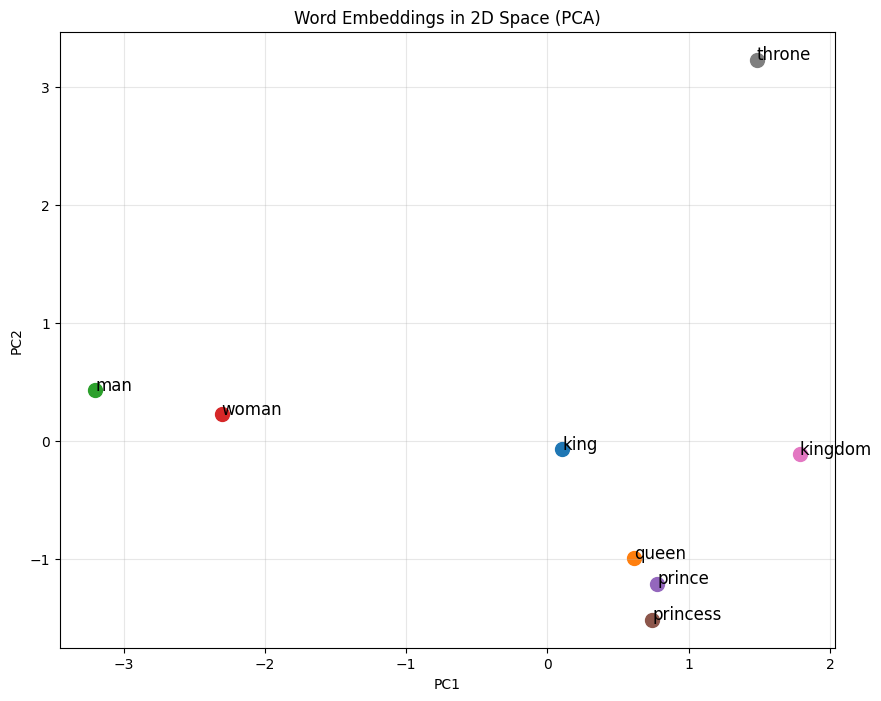


Note: Embeddings capture semantic relationships!
Similar words cluster together in embedding space.


In [18]:
# ============================================================
# 3. Visualize Embedding Space (PCA)
# ============================================================

print("="*70)
print("EMBEDDING SIMILARITY")
print("="*70)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get embeddings for related words
words = ["king", "queen", "man", "woman", "prince", "princess", "kingdom", "throne"]

# Get embeddings
word_embeddings = []
valid_words = []

for word in words:
    token_id = tokenizer.convert_tokens_to_ids(word)
    if token_id != tokenizer.unk_token_id:
        embedding = embedding_matrix[token_id]
        word_embeddings.append(embedding)
        valid_words.append(word)

word_embeddings = np.array(word_embeddings)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(word_embeddings)

print(f"Projected {len(valid_words)} words to 2D space")
print(f"Explained variance: {sum(pca.explained_variance_ratio_):.2%}")

plt.figure(figsize=(10, 8))
for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y, s=100)
    plt.annotate(valid_words[i], (x, y), fontsize=12)
plt.title('Word Embeddings in 2D Space (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

print("\nNote: Embeddings capture semantic relationships!")
print("Similar words cluster together in embedding space.")

### 🎯 Key Properties of Good Embeddings

1. **Semantic Similarity**: Similar words have similar vectors
   - `cosine_similarity(king, queen) > cosine_similarity(king, apple)`

2. **Linear Relationships**: Embeddings support arithmetic
   - `king - man + woman ≈ queen`

3. **Context Sensitivity**: Modern models adjust embeddings based on context
   - "bank" in "river bank" ≠ "bank" in "bank account"

---

## 7. Contextualized Word Embeddings


### 🔄 Static vs Contextualized Embeddings

| Feature | Static (Word2Vec, GloVe) | Contextualized (BERT, GPT) |
|---------|--------------------------|----------------------------|
| **Same word, different context** | Same vector | Different vectors |
| **Polysemy handling** | ❌ Poor (one vector per word) | ✅ Excellent |
| **Example** | "bank" = same vector always | "bank" differs in "river bank" vs "bank account" |
| **Training** | Shallow neural networks | Deep Transformers |
| **Use Cases** | Simple NLP, recommendations | Modern NLP, LLMs |

### 💡 Why Contextualized Embeddings Matter

**Example:**
```python
# Static embeddings (Word2Vec)
"bank" → [0.23, -0.45, 0.67, ...]  # Same everywhere!

# Contextualized embeddings (BERT)
"I went to the bank" → [0.23, -0.45, 0.67, ...]
"The river bank" → [0.18, -0.52, 0.71, ...]  # Different!


In [19]:
# ============================================================
# CONTEXTUALIZED EMBEDDINGS IN ACTION
# ============================================================

from transformers import AutoModel, AutoTokenizer
import torch
import numpy as np

print("="*70)
print("CONTEXTUALIZED VS STATIC EMBEDDINGS")
print("="*70)

# Load model
MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

CONTEXTUALIZED VS STATIC EMBEDDINGS


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
# ============================================================
# 1. Same Word, Different Contexts
# ============================================================

contexts = [
    "I went to the bank to deposit money.",
    "The river bank was covered in flowers.",
    "The bank approved my loan application.",
    "We sat on the grassy bank of the stream.",
]

print("\nAnalyzing 'bank' in different contexts:\n")

bank_embeddings = []

for i, sentence in enumerate(contexts, 1):
    # Tokenize
    inputs = tokenizer(sentence, return_tensors="pt")
    token_ids = inputs['input_ids'][0]

    # Get contextualized embeddings
    with torch.no_grad():
        outputs = model(**inputs)

    token_embeddings = outputs.last_hidden_state[0]
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Find 'bank' token
    for j, token in enumerate(tokens):
        if token == "bank":
            embedding = token_embeddings[j].numpy()
            bank_embeddings.append(embedding)

            print(f"Context {i}: {sentence}")
            print(f"  'bank' embedding (first 5): {embedding[:5]}")
            print(f"  Surrounding tokens: {tokens[max(0,j-2):j+3]}")
            print()



Analyzing 'bank' in different contexts:



model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

In [21]:
# ============================================================
# 2. Compare Embedding Similarity
# ============================================================

print("="*70)
print("EMBEDDING SIMILARITY ANALYSIS")
print("="*70)

def cosine_similarity(v1, v2):
    """Calculate cosine similarity between two vectors"""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Compare all pairs
print("\nSimilarity between 'bank' embeddings in different contexts:")
print("(1.0 = identical, 0.0 = completely different)\n")

for i in range(len(bank_embeddings)):
    for j in range(i+1, len(bank_embeddings)):
        sim = cosine_similarity(bank_embeddings[i], bank_embeddings[j])
        print(f"Context {i+1} vs Context {j+1}: {sim:.4f}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("✓ High similarity (>0.95): Same meaning")
print("✓ Medium similarity (0.85-0.95): Related but different contexts")
print("✓ Low similarity (<0.85): Completely different meanings")
print("\nContextualized embeddings capture these nuances!")

EMBEDDING SIMILARITY ANALYSIS

Similarity between 'bank' embeddings in different contexts:
(1.0 = identical, 0.0 = completely different)


INTERPRETATION
✓ High similarity (>0.95): Same meaning
✓ Medium similarity (0.85-0.95): Related but different contexts
✓ Low similarity (<0.85): Completely different meanings

Contextualized embeddings capture these nuances!


In [22]:
# ============================================================
# 3. Compare with Static Embeddings (Word2Vec)
# ============================================================

print("\n" + "="*70)
print("STATIC VS CONTEXTUALIZED COMPARISON")
print("="*70)

try:
    import gensim.downloader as api

    print("\nLoading GloVe embeddings...")
    static_model = api.load("glove-wiki-gigaword-50")

    # Static embedding for "bank"
    static_embedding = static_model["bank"]
    print(f"\nStatic embedding (GloVe):")
    print(f"  'bank' → {static_embedding[:5]}")
    print(f"  Same vector for ALL contexts!")

    print(f"\nContextualized embeddings (DeBERTa):")
    for i, emb in enumerate(bank_embeddings[:2], 1):
        print(f"  Context {i} → {emb[:5]}")
    print(f"  Different vector for EACH context!")

except ImportError:
    print("\nInstall gensim to compare with static embeddings:")
    print("!pip install gensim")



STATIC VS CONTEXTUALIZED COMPARISON

Install gensim to compare with static embeddings:
!pip install gensim


### 🎯 Applications of Contextualized Embeddings

1. **Named Entity Recognition (NER)**: Identify people, places, organizations
2. **Extractive Summarization**: Find most important sentences
3. **Question Answering**: Match questions to answer spans
4. **Text Classification**: Sentiment analysis, topic classification

---

## 8. Text Embeddings


### 📄 From Token to Text Embeddings

While token embeddings represent individual words, **text embeddings** (or sentence embeddings) represent entire sentences, paragraphs, or documents as single vectors.

**Why Text Embeddings?**

- **Semantic Search**: Find documents similar in meaning (not just keywords)
- **Clustering**: Group similar documents together
- **Recommendation**: Recommend similar articles/products
- **RAG (Retrieval-Augmented Generation)**: Retrieve relevant context for LLMs

### 🛠️ How Text Embeddings Work

**Pooling Strategies:**

1. **Mean Pooling**: Average all token embeddings
2. **Max Pooling**: Take max value across all tokens
3. **CLS Pooling**: Use the `[CLS]` token embedding
4. **Weighted Pooling**: Weight tokens by importance


In [23]:
# ============================================================
# TEXT EMBEDDINGS WITH SENTENCE TRANSFORMERS
# ============================================================

# Install if needed
# !pip install sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

print("="*70)
print("TEXT EMBEDDINGS DEMONSTRATION")
print("="*70)

TEXT EMBEDDINGS DEMONSTRATION


In [24]:
# ============================================================
# 1. Load Sentence Embedding Model
# ============================================================

# Choose model based on your needs:
# - all-MiniLM-L6-v2: Fast, 384-dim, good quality
# - all-mpnet-base-v2: Better quality, 768-dim, slower
# - paraphrase-MiniLM-L6-v2: Optimized for similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Model: all-MiniLM-L6-v2")
print(f"Embedding Dimension: 384")
print(f"Max Sequence Length: 256 tokens")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model: all-MiniLM-L6-v2
Embedding Dimension: 384
Max Sequence Length: 256 tokens


In [25]:
# ============================================================
# 2. Generate Text Embeddings
# ============================================================

print("\n" + "="*70)
print("GENERATING TEXT EMBEDDINGS")
print("="*70)

sentences = [
    "The cat sat on the mat.",
    "A cat is sitting on the mat.",
    "The dog is running in the park.",
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "Machine learning is fascinating.",
    "Deep learning uses neural networks.",
]

# Generate embeddings
embeddings = model.encode(sentences)

print(f"\nGenerated {len(embeddings)} embeddings")
print(f"Shape: {embeddings.shape}")
print(f"  - {embeddings.shape[0]} sentences")
print(f"  - {embeddings.shape[1]} dimensions each")

# Display first few values
print("\nFirst 5 values of each embedding:")
for i, (sentence, embedding) in enumerate(zip(sentences, embeddings), 1):
    print(f"{i}. '{sentence[:40]}...' → {embedding[:5]}")


GENERATING TEXT EMBEDDINGS

Generated 7 embeddings
Shape: (7, 384)
  - 7 sentences
  - 384 dimensions each

First 5 values of each embedding:
1. 'The cat sat on the mat....' → [ 0.13023718 -0.01577283 -0.03671666  0.05798642 -0.05979174]
2. 'A cat is sitting on the mat....' → [ 0.11869872 -0.03982474 -0.03454119  0.04049729 -0.04794603]
3. 'The dog is running in the park....' → [ 0.04488827 -0.05070224  0.04554842 -0.0020296   0.0519786 ]
4. 'I love programming in Python....' → [-0.057617    0.0042623  -0.02815311  0.02519761 -0.01650563]
5. 'Python is my favorite programming langua...' → [-0.07462104 -0.02730316 -0.00611454  0.0053535  -0.02248997]
6. 'Machine learning is fascinating....' → [-0.02140392 -0.09899698  0.09297428  0.01137601 -0.0092419 ]
7. 'Deep learning uses neural networks....' → [-0.06878828 -0.04169563  0.06110685 -0.00557465 -0.008479  ]


In [26]:
# ============================================================
# 3. Semantic Similarity
# ============================================================

print("\n" + "="*70)
print("SEMANTIC SIMILARITY CALCULATION")
print("="*70)

def calculate_similarity(text1, text2):
    """Calculate semantic similarity between two texts"""
    emb1 = model.encode([text1])
    emb2 = model.encode([text2])
    similarity = cosine_similarity(emb1, emb2)[0][0]
    return similarity

# Test pairs
test_pairs = [
    ("The cat sat on the mat", "A cat is sitting on the rug"),
    ("The cat sat on the mat", "The dog is running in the park"),
    ("I love programming in Python", "Python is my favorite language"),
    ("I love programming in Python", "I enjoy baking cakes"),
    ("Machine learning is fascinating", "Deep learning uses neural networks"),
]

print("\nSemantic Similarity Scores:")
print("(1.0 = identical meaning, 0.0 = completely different)\n")

for text1, text2 in test_pairs:
    similarity = calculate_similarity(text1, text2)
    print(f"Text 1: {text1}")
    print(f"Text 2: {text2}")
    print(f"Similarity: {similarity:.4f}")
    print("-" * 70)


SEMANTIC SIMILARITY CALCULATION

Semantic Similarity Scores:
(1.0 = identical meaning, 0.0 = completely different)

Text 1: The cat sat on the mat
Text 2: A cat is sitting on the rug
Similarity: 0.7095
----------------------------------------------------------------------
Text 1: The cat sat on the mat
Text 2: The dog is running in the park
Similarity: 0.0269
----------------------------------------------------------------------
Text 1: I love programming in Python
Text 2: Python is my favorite language
Similarity: 0.8327
----------------------------------------------------------------------
Text 1: I love programming in Python
Text 2: I enjoy baking cakes
Similarity: 0.2554
----------------------------------------------------------------------
Text 1: Machine learning is fascinating
Text 2: Deep learning uses neural networks
Similarity: 0.4898
----------------------------------------------------------------------


In [27]:
# ============================================================
# 4. Semantic Search
# ============================================================

print("\n" + "="*70)
print("SEMANTIC SEARCH EXAMPLE")
print("="*70)

# Document corpus
documents = [
    "Machine learning is a subset of artificial intelligence.",
    "Deep learning uses neural networks with many layers.",
    "Natural language processing deals with human language.",
    "Computer vision focuses on visual data processing.",
    "Reinforcement learning learns from interaction with environment.",
    "Supervised learning requires labeled training data.",
    "Unsupervised learning finds patterns in unlabeled data.",
]

def semantic_search(query, documents, top_k=3):
    """Find most semantically similar documents"""
    # Encode query and documents
    query_embedding = model.encode([query])
    doc_embeddings = model.encode(documents)

    # Calculate similarities
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Get top K
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'document': documents[idx],
            'similarity': similarities[idx]
        })

    return results

# Test search
query = "What is deep learning?"
print(f"\nQuery: {query}\n")

results = semantic_search(query, documents, top_k=3)

print("Top 3 Most Similar Documents:\n")
for i, result in enumerate(results, 1):
    print(f"{i}. Similarity: {result['similarity']:.4f}")
    print(f"   {result['document']}")
    print()


SEMANTIC SEARCH EXAMPLE

Query: What is deep learning?

Top 3 Most Similar Documents:

1. Similarity: 0.6973
   Deep learning uses neural networks with many layers.

2. Similarity: 0.5403
   Machine learning is a subset of artificial intelligence.

3. Similarity: 0.3281
   Supervised learning requires labeled training data.



In [28]:
# ============================================================
# 5. Document Clustering
# ============================================================

print("="*70)
print("DOCUMENT CLUSTERING")
print("="*70)

from sklearn.cluster import KMeans

# Cluster documents
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

print(f"\nClustered {len(documents)} documents into {n_clusters} groups:\n")

for cluster_id in range(n_clusters):
    cluster_docs = [documents[i] for i in range(len(documents)) if clusters[i] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_docs)} documents):")
    for doc in cluster_docs:
        print(f"  • {doc}")
    print()

DOCUMENT CLUSTERING

Clustered 7 documents into 3 groups:

Cluster 0 (1 documents):
  • Natural language processing deals with human language.

Cluster 1 (4 documents):
  • Computer vision focuses on visual data processing.
  • Reinforcement learning learns from interaction with environment.
  • Supervised learning requires labeled training data.
  • Unsupervised learning finds patterns in unlabeled data.

Cluster 2 (2 documents):
  • Machine learning is a subset of artificial intelligence.
  • Deep learning uses neural networks with many layers.



In [29]:
# ============================================================
# 6. Use Case: RAG (Retrieval-Augmented Generation)
# ============================================================

print("="*70)
print("RAG USE CASE: Retrieve Context for LLM")
print("="*70)

def retrieve_context(query, documents, top_k=2):
    """Retrieve most relevant context for a query"""
    results = semantic_search(query, documents, top_k)
    context = "\n\n".join([r['document'] for r in results])
    return context

# Example: User asks a question
user_question = "How does deep learning work?"

# Retrieve relevant context
context = retrieve_context(user_question, documents, top_k=2)

print(f"\nUser Question: {user_question}")
print(f"\nRetrieved Context:")
print(context)
print(f"\n[This context would be passed to an LLM to generate an answer]")


RAG USE CASE: Retrieve Context for LLM

User Question: How does deep learning work?

Retrieved Context:
Deep learning uses neural networks with many layers.

Machine learning is a subset of artificial intelligence.

[This context would be passed to an LLM to generate an answer]


### 🎯 Best Practices for Text Embeddings

1. **Choose the Right Model**:
   - **Speed**: `all-MiniLM-L6-v2` (fast, good enough)
   - **Quality**: `all-mpnet-base-v2` (slower, better)
   - **Multilingual**: `paraphrase-multilingual-MiniLM-L12-v2`

2. **Normalize Embeddings**: Use cosine similarity (not Euclidean distance)

3. **Batch Processing**: Encode multiple texts at once for speed

4. **Dimensionality**: Higher dimensions = better quality but more storage

---

## 9. Word2Vec & Recommendation Systems

Before massive LLMs, researchers used algorithms like **word2vec** to create static embeddings. It relied on two massive concepts that are still used today:

1.  **Skip-Gram (Sliding Window):** The algorithm looks at a sentence and pairs a "center word" with its neighboring words.

2.  **Negative Sampling:** To train the neural network, you feed it the correct neighbor pairs (Target = 1), but you also feed it random, completely unrelated words (Negative Examples, Target = 0). The model learns by contrasting the real relationships against the fake ones.


Because of this, we can use the exact same algorithm to embed *anything* that acts like a sequence—including user behavior!



###  From Words to Songs: Embedding Anything

The **Word2Vec** algorithm revolutionized embeddings by learning vector representations from context. The key insight:

> "You shall know a word by the company it keeps" - J.R. Firth

**Two Core Ideas:**

1. **Skip-gram**: Predict surrounding words from a center word
2. **Negative Sampling**: Train on positive examples (real neighbors) + negative examples (random words)

### 🎼 Application: Music Recommendation

If we treat a **Playlist** like a "sentence", and a **Song** like a "word/token", we can use `Word2Vec` to learn song embeddings. Songs that frequently appear next to each other in playlists will end up closer together in the vector space!


**Brilliant Analogy:**
- **Playlist** = Sentence
- **Song** = Word
- **Songs that appear together** = Words that appear together

Train Word2Vec on playlists → Get song embeddings → Recommend similar songs!



In [30]:
# ============================================================
# INSTALL REQUIRED LIBRARIES (Run this first!)
# ============================================================
!pip install -q gensim pandas numpy

# ============================================================
# MUSIC RECOMMENDATION SYSTEM WITH WORD2VEC
# ============================================================

import pandas as pd
from urllib import request
from gensim.models import Word2Vec
import numpy as np

print("="*70)
print("BUILDING A MUSIC RECOMMENDATION SYSTEM")
print("="*70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.4 MB/s eta 0:00:00
BUILDING A MUSIC RECOMMENDATION SYSTEM


In [31]:
# ============================================================
# 1. Load Playlist Dataset
# ============================================================

def load_data():
    """Load playlist data from Cornell University dataset"""

    print("\n[1/4] Loading playlist data...")

    # Download playlist data
    data_url = 'https://storage.googleapis.com/maps-premium/dataset/yes_complete/train.txt'
    data = request.urlopen(data_url).read().decode("utf-8").split('\n')[2:]

    # Parse playlists (keep only playlists with >1 song)
    playlists = [s.rstrip().split() for s in data if len(s.split()) > 1]

    print(f"✓ Loaded {len(playlists):,} playlists")
    print(f"✓ Average playlist length: {np.mean([len(p) for p in playlists]):.1f} songs")

    # Download song metadata
    print("\n[2/4] Loading song metadata...")
    songs_url = 'https://storage.googleapis.com/maps-premium/dataset/yes_complete/song_hash.txt'
    songs_file = request.urlopen(songs_url).read().decode("utf-8").split('\n')

    # Parse metadata
    songs = [s.rstrip().split('\t') for s in songs_file if s.strip()]
    songs_df = pd.DataFrame(data=songs, columns=['id', 'title', 'artist'])
    songs_df = songs_df.set_index('id')

    print(f"✓ Loaded {len(songs_df):,} songs")

    return playlists, songs_df

# Load data
playlists, songs_df = load_data()


[1/4] Loading playlist data...
✓ Loaded 11,088 playlists
✓ Average playlist length: 170.3 songs

[2/4] Loading song metadata...
✓ Loaded 75,262 songs


In [32]:
# ============================================================
# 2. Train Word2Vec Model
# ============================================================

print("\n[3/4] Training Word2Vec model...")
print("(This treats each playlist as a 'sentence' and songs as 'words')")

# Train Word2Vec
model = Word2Vec(
    playlists,
    vector_size=32,          # 32-dimensional embeddings
    window=20,               # Consider 20 songs before/after as context
    negative=50,             # 50 negative samples per positive
    min_count=1,             # Include all songs (even rare ones)
    workers=4,               # Use 4 CPU threads
    sg=1,                    # Skip-gram (vs CBOW)
    epochs=10                # Train for 10 epochs
)

print(f"✓ Model trained!")
print(f"✓ Vocabulary: {len(model.wv.key_to_index):,} songs")
print(f"✓ Embedding dimension: {model.wv.vector_size}")


[3/4] Training Word2Vec model...
(This treats each playlist as a 'sentence' and songs as 'words')
✓ Model trained!
✓ Vocabulary: 75,261 songs
✓ Embedding dimension: 32


In [33]:
# ============================================================
# 3. Recommendation Function
# ============================================================

def get_recommendations(song_id, model, songs_df, top_n=5):
    """Get song recommendations based on embeddings"""

    try:
        # Find similar songs in embedding space
        similar = model.wv.most_similar(str(song_id), topn=top_n)

        # Get metadata
        recommendations = []
        for sim_song_id, similarity_score in similar:
            song_info = songs_df.iloc[int(sim_song_id)]
            recommendations.append({
                'id': sim_song_id,
                'title': song_info['title'],
                'artist': song_info['artist'],
                'similarity': similarity_score
            })

        return recommendations

    except KeyError:
        return None

def print_recommendations(song_id, model, songs_df, top_n=5):
    """Pretty print recommendations"""

    # Get original song info
    try:
        original_song = songs_df.iloc[song_id]
        print(f"\n{'='*70}")
        print(f"🎵 Songs similar to:")
        print(f"   '{original_song['title']}' by {original_song['artist']}")
        print(f"{'='*70}\n")
    except:
        print(f"\nSong ID {song_id} not found\n")
        return

    # Get recommendations
    recs = get_recommendations(song_id, model, songs_df, top_n)

    if recs is None:
        print("Song not in training data")
        return

    # Print recommendations
    print(f"{'#':<4} {'Title':<35} {'Artist':<25} {'Score':>8}")
    print("-" * 70)

    for i, rec in enumerate(recs, 1):
        print(f"{i:<4} {rec['title']:<35} {rec['artist']:<25} {rec['similarity']:.4f}")


In [34]:
# ============================================================
# 4. Test the Recommender
# ============================================================

print("\n[4/4] Testing the recommendation system...")

# Test songs
test_songs = [
    2172,   # "Fade to Black" by Metallica
    3822,   # "Billie Jean" by Michael Jackson
    842,    # "California Love" by 2Pac
]

for song_id in test_songs:
    print_recommendations(song_id, model, songs_df, top_n=5)

# ============================================================
# 5. Explore Embedding Space
# ============================================================

print("\n" + "="*70)
print("EXPLORING THE EMBEDDING SPACE")
print("="*70)

# Find songs similar to multiple artists
def find_cross_artist_similarity(artist1, artist2, model, songs_df, top_n=3):
    """Find songs that bridge two artists"""

    # Get songs by each artist
    artist1_songs = songs_df[songs_df['artist'] == artist1].index.tolist()[:5]
    artist2_songs = songs_df[songs_df['artist'] == artist2].index.tolist()[:5]

    print(f"\nBridging {artist1} and {artist2}:")

    for song1_id in artist1_songs[:1]:
        try:
            similar = model.wv.most_similar(str(song1_id), topn=top_n*3)

            for sim_id, score in similar:
                if sim_id in artist2_songs:
                    song_info = songs_df.iloc[int(sim_id)]
                    print(f"  {song_info['title']} by {song_info['artist']} (similarity: {score:.4f})")
        except:
            pass

# Example: Find connections between artists
find_cross_artist_similarity("Metallica", "Iron Maiden", model, songs_df)




[4/4] Testing the recommendation system...

🎵 Songs similar to:
   'Fade To Black' by Metallica

#    Title                               Artist                       Score
----------------------------------------------------------------------
1    For Whom The Bell Tolls             Metallica                 0.9792
2    Sad But True                        Metallica                 0.9621
3    Wherever I May Roam                 Metallica                 0.9592
4    Run To The Hills                    Iron Maiden               0.9556
5    Kickstart My Heart                  Motley Crue               0.9538

🎵 Songs similar to:
   'Billie Jean' by Michael Jackson

#    Title                               Artist                       Score
----------------------------------------------------------------------
1    When Doves Cry                      Prince & The Revolution   0.9519
2    Straight Up                         Paula Abdul               0.9257
3    Don't Stop 'Til You Get Eno

In [35]:
# ============================================================
# 6. Vector Arithmetic with Songs
# ============================================================

print("\n" + "="*70)
print("VECTOR ARITHMETIC WITH SONGS")
print("="*70)

def song_vector_arithmetic(positive_songs, negative_songs, model, songs_df, top_n=3):
    """Perform vector arithmetic: song1 - song2 + song3 = ?"""

    try:
        # Get song IDs as strings
        positive_ids = [str(sid) for sid in positive_songs]
        negative_ids = [str(sid) for sid in negative_songs]

        # Find most similar
        result = model.wv.most_similar(positive=positive_ids, negative=negative_ids, topn=top_n)

        print(f"\n{' + '.join([songs_df.iloc[sid]['title'][:20] for sid in positive_songs])}", end="")
        if negative_songs:
            print(f" - {' - '.join([songs_df.iloc[sid]['title'][:20] for sid in negative_songs])}", end="")
        print(" ≈\n")

        for song_id, score in result:
            song_info = songs_df.iloc[int(song_id)]
            print(f"  {song_info['title']} by {song_info['artist']} ({score:.4f})")

    except Exception as e:
        print(f"Error: {e}")

# Example: Metallica + Pop = ?
# song_vector_arithmetic([2172, 3822], [], model, songs_df)

print("\n" + "="*70)
print("RECOMMENDATION SYSTEM COMPLETE!")
print("="*70)
print("\nKey Insights:")
print("✓ Word2Vec works for ANY sequential data (songs, products, users)")
print("✓ Playlists reveal song similarity through co-occurrence")
print("✓ Embedding space captures genre, mood, and style")
print("✓ Vector arithmetic can find interesting combinations")


VECTOR ARITHMETIC WITH SONGS

RECOMMENDATION SYSTEM COMPLETE!

Key Insights:
✓ Word2Vec works for ANY sequential data (songs, products, users)
✓ Playlists reveal song similarity through co-occurrence
✓ Embedding space captures genre, mood, and style
✓ Vector arithmetic can find interesting combinations


### 🎯 Why This Works

1. **Co-occurrence = Similarity**: Songs that appear together in playlists are similar
2. **Context Matters**: A song's "meaning" is defined by the songs around it
3. **Transfer Learning**: Same algorithm works for words, songs, products, users

### 📊 Generalization to Other Domains

| Domain | "Sentence" | "Word" | Application |
|--------|------------|--------|-------------|
| **Text** | Document | Word | Word embeddings |
| **Music** | Playlist | Song | Song recommendations |
| **E-commerce** | Shopping cart | Product | Product recommendations |
| **Social Media** | User's posts | Hashtag | Hashtag recommendations |
| **Academia** | Paper | Citation | Paper recommendations |

---


## 10. Interview Questions


###  Tokenization Questions

**Q1: What is tokenization and why is it important?**

**Answer:**
Tokenization is the process of breaking down text into smaller units (tokens) that LLMs can process. It's important because:
- LLMs can't process raw text; they need numeric representations
- Affects model efficiency, context window usage, and performance
- Different tokenizers handle different languages, code, and special characters

---

**Q2: Explain the difference between word, subword, character, and byte tokenization.**

**Answer:**

| Method | Example | Pros | Cons |
|--------|---------|------|------|
| **Word** | `["playing", "tennis"]` | Simple, intuitive | Can't handle new words, huge vocabulary |
| **Subword** | `["play", "ing", "ten", "nis"]` | Handles new words, efficient vocab | More complex |
| **Character** | `["p", "l", "a", "y", "i", "n", "g"]` | Smallest vocab, handles everything | Very long sequences |
| **Byte** | `[112, 108, 97, 121, ...]` | Universal | Longest sequences, expensive |

---

**Q3: What is the difference between BPE and WordPiece?**

**Answer:**

**BPE (Byte Pair Encoding):**
- Starts with characters, merges most frequent pairs
- Used by GPT-2, GPT-4, Llama
- Merges based on frequency

**WordPiece:**
- Similar to BPE but uses likelihood instead of frequency
- Used by BERT
- Chooses merges that maximize likelihood of training data

Both are subword tokenization methods but use different criteria for merging.

---

**Q4: Why do modern LLMs use subword tokenization instead of word tokenization?**

**Answer:**

1. **Vocabulary Size**: Subword needs ~30K-100K tokens vs millions for word-level
2. **New Words**: Can handle unseen words by breaking them into known subwords
3. **Efficiency**: Better context window utilization (~3x more text)
4. **Multilingual**: Shares subwords across languages
5. **Morphology**: Handles different word forms efficiently (play, playing, played)

---

**Q5: What are special tokens and why are they used?**

**Answer:**

Special tokens serve specific purposes:
- **`<s>` / `</s>`**: Start/end of text
- **`<pad>`**: Padding sequences to same length
- **`<unk>`**: Unknown tokens not in vocabulary
- **`<cls>`**: Classification token (BERT)
- **`<sep>`**: Separator between sentences
- **`<|user|>` / `<|assistant|>`**: Chat turn markers

They help the model understand structure and perform specific tasks.

---

### 📊 Embedding Questions

**Q6: What are embeddings and why are they useful?**

**Answer:**

Embeddings are dense vector representations that capture semantic meaning:
- Convert discrete tokens into continuous vectors
- Similar words have similar vectors
- Support arithmetic operations (king - man + woman ≈ queen)
- Enable machines to understand semantic relationships

---

**Q7: What's the difference between static and contextualized embeddings?**

**Answer:**

| Feature | Static (Word2Vec) | Contextualized (BERT) |
|---------|-------------------|----------------------|
| **Same word** | Same vector always | Different vectors per context |
| **Polysemy** | Can't handle | Handles well |
| **Example** | "bank" = one vector | "bank" differs in "river bank" vs "bank account" |
| **Training** | Shallow networks | Deep Transformers |

---

**Q8: Explain the word2vec training process.**

**Answer:**

Word2Vec uses two main approaches:

**Skip-gram:**
- Input: Center word
- Output: Predict surrounding context words
- Good for rare words

**CBOW (Continuous Bag of Words):**
- Input: Context words
- Output: Predict center word
- Faster, good for frequent words

**Negative Sampling:**
- Train on positive examples (real word pairs)
- Also train on negative examples (random word pairs)
- Model learns to distinguish real from fake pairs

---

**Q9: How do you calculate similarity between embeddings?**

**Answer:**

**Cosine Similarity** (most common):
```python
similarity = (A · B) / (||A|| × ||B||)
```
- Measures angle between vectors
- Range: -1 (opposite) to 1 (identical)
- Ignores magnitude, focuses on direction

**Euclidean Distance:**
- Measures straight-line distance
- Affected by magnitude
- Less common for embeddings

---

**Q10: What is the dimensionality of embeddings and how do you choose it?**

**Answer:**

**Common dimensions:**
- Word2Vec: 50-300
- BERT: 768 (base), 1024 (large)
- GPT: 768-4096+

**Trade-offs:**
- **Higher dimensions**: More expressive, better quality, more compute/storage
- **Lower dimensions**: Faster, less storage, may lose information

**Choice depends on:**
- Task complexity
- Available compute
- Vocabulary size
- Dataset size

---

### 🔧 Application Questions

**Q11: How would you build a semantic search engine?**

**Answer:**

1. **Choose embedding model**: Sentence-BERT, all-mpnet-base-v2
2. **Preprocess documents**: Clean, chunk if needed
3. **Generate embeddings**: Encode all documents
4. **Store embeddings**: In vector database (FAISS, Pinecone, Weaviate)
5. **Query processing**: Encode user query
6. **Similarity search**: Find nearest neighbors using cosine similarity
7. **Rank and return**: Top K most similar documents

**Code:**
```python
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')
doc_embeddings = model.encode(documents)
query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, doc_embeddings)
```

---

**Q12: How can embeddings be used for recommendation systems?**

**Answer:**

**Approach 1: Content-based**
- Embed item descriptions
- Recommend items with similar embeddings

**Approach 2: Collaborative filtering**
- Use Word2Vec on user behavior sequences
- Items that appear together have similar embeddings

**Approach 3: Hybrid**
- Combine content and collaborative embeddings
- Better recommendations than either alone

**Example:**
```python
# Song recommendations
model = Word2Vec(playlists, vector_size=32, window=20)
similar_songs = model.wv.most_similar("song_id_123")
```

---

**Q13: What is the "curse of dimensionality" and how does it affect embeddings?**

**Answer:**

**Curse of Dimensionality:**
- As dimensions increase, data becomes sparse
- Distance metrics become less meaningful
- All points appear equidistant

**Impact on embeddings:**
- Too few dimensions: Can't capture complexity
- Too many dimensions: Sparse, overfitting, slow

**Solution:**
- Choose appropriate dimensionality (typically 100-1000)
- Use dimensionality reduction (PCA, t-SNE) for visualization
- Regularization during training

---

**Q14: How do you handle out-of-vocabulary (OOV) words?**

**Answer:**

**Strategies:**

1. **Subword tokenization**: Break OOV into known subwords
   - "ChatGPT" → "Chat" + "G" + "PT"

2. **Character-level fallback**: Use character embeddings

3. **Use `<unk>` token**: Replace OOV with unknown token

4. **Dynamic embeddings**: Generate embeddings on-the-fly

5. **FastText**: Uses character n-grams, can handle OOV

---

**Q15: Explain how you would visualize high-dimensional embeddings.**

**Answer:**

**Dimensionality Reduction Techniques:**

1. **PCA (Principal Component Analysis)**:
   - Linear method
   - Fast, preserves global structure
   - Good for initial exploration

2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**:
   - Non-linear
   - Preserves local structure
   - Better for clustering visualization
   - Slower

3. **UMAP (Uniform Manifold Approximation and Projection)**:
   - Non-linear
   - Faster than t-SNE
   - Preserves both local and global structure

**Code:**
```python
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
```



---

## 11. Mind Maps


###  Chapter 2 Mind Map

```
┌─────────────────────────────────────────────────────────────────┐
│                    TOKENS & EMBEDDINGS                          │
└─────────────────────────────────────────────────────────────────┘
                              │
              ┌───────────────┴───────────────┐
              │                               │
         TOKENIZATION                   EMBEDDINGS
              │                               │
    ┌─────────┴─────────┐           ┌────────┴────────
    │                   │           │                 │
  METHODS           COMPARISON    TYPES          APPLICATIONS
    │                   │           │                 │
    ├─ Word             ├─ BERT     ├─ Token          ├─ Semantic Search
    ├─ Subword          ├─ GPT      ├─ Contextualized ├─ Recommendations
    ├─ Character        ├─ Llama    ├─ Text/Sentence  ├─ Clustering
    └─ Byte             └─ Special  └─ Word2Vec       └─ RAG
```

### 📊 Tokenization Methods Mind Map

```
┌─────────────────────────────────────────────────────────────┐
│                    TOKENIZATION METHODS                      │
└─────────────────────────────────────────────────────────────┘
                            │
        ┌───────────────────┼───────────────────┐
        │                   │                   │
    WORD TOKENS       SUBWORD TOKENS      CHARACTER/BYTE
        │                   │                   │
        ├─ Simple           ├─ BPE              ├─ Character-level
        ├─ Intuitive        ├─ WordPiece        └─ Byte-level
        └─ Large vocab      ├─ SentencePiece        (tokenization-free)
                            │
                            ├─ Efficient vocab
                            ├─ Handles new words
                            └─ Best for LLMs
```

### 🎯 Embedding Types Mind Map

```
┌─────────────────────────────────────────────────────────────┐
│                    EMBEDDING TYPES                           │
└─────────────────────────────────────────────────────────────┘
                            │
        ┌───────────────────┼───────────────────┐
        │                   │                   │
    STATIC            CONTEXTUALIZED       TEXT/SENTENCE
        │                   │                   │
        ├─ Word2Vec         ├─ BERT             ├─ Sentence-BERT
        ├─ GloVe            ├─ GPT              ├─ all-MiniLM
        └─ FastText         └─ DeBERTa          └─ all-mpnet
                            │
                            ├─ Context-aware
                            ├─ Polysemy handling
                            └─ Modern LLMs
```

### 🔧 Applications Mind Map

```
┌─────────────────────────────────────────────────────────────┐
│                 EMBEDDING APPLICATIONS                       │
└─────────────────────────────────────────────────────────────┘
                            │
        ┌───────────────────┼───────────────────┐
        │                   │                   │
    NLP TASKS         SEARCH & REC       ADVANCED USES
        │                   │                   │
        ├─ NER              ├─ Semantic Search  ├─ RAG
        ├─ Classification   ├─ Recommendations  ├─ Clustering
        ├─ Summarization    └─ Clustering       ├─ Question Answering
        └─ Translation                          └─ Transfer Learning
```

### 🎵 Word2Vec to Recommendations Mind Map

```
┌─────────────────────────────────────────────────────────────┐
│              WORD2VEC → RECOMMENDATIONS                      │
└─────────────────────────────────────────────────────────────┘
                            │
        ┌───────────────────┼───────────────────┐
        │                   │                   │
    TRAINING           EMBEDDING          APPLICATIONS
        │                   │                   │
        ├─ Skip-gram        ├─ Vector space     ├─ Music (playlists)
        ├─ CBOW             ├─ Similarity       ├─ Products (carts)
        ├─ Negative samp.   └─ Arithmetic       ├─ Users (behavior)
        │                                       └─ Papers (citations)
        └─ Co-occurrence = Similarity
```

---



## 📚 Summary & Key Takeaways


### ✅ What You Learned

1. **Tokenization**: Breaking text into processable units (words, subwords, characters, bytes)
2. **Subword Dominance**: Modern LLMs use subword tokenization (BPE, WordPiece) for efficiency
3. **Specialized Tokenizers**: Different models optimize for code, science, chat, etc.
4. **Embeddings**: Numeric vectors capturing semantic meaning
5. **Contextualized Embeddings**: Modern embeddings that change based on context
6. **Text Embeddings**: Single vectors representing entire sentences/documents
7. **Word2Vec**: Revolutionary algorithm still useful for recommendations
8. **Applications**: Semantic search, clustering, RAG, recommendations

### 🎯 Key Formulas

**Cosine Similarity:**
```
similarity = (A · B) / (||A|| × ||B||)
```

**Token Efficiency:**
```
Subword: ~3-4 characters per token
Character: 1 character per token
```

### 📊 Quick Reference

| Concept | Typical Values | Best For |
|---------|---------------|----------|
| **Vocab Size** | 30K-100K | Balance efficiency & coverage |
| **Embedding Dim** | 384-1024 | Quality vs speed trade-off |
| **Context Window** | 512-4096 tokens | Depends on task |
| **Similarity Threshold** | >0.8 = similar | Semantic search |

### 🚀 Next Steps

1. **Practice**: Implement tokenization and embeddings yourself
2. **Experiment**: Try different models (BERT, GPT, Sentence-BERT)
3. **Build**: Create a semantic search or recommendation system
4. **Deepen**: Study Transformer architecture (Chapter 3)
5. **Apply**: Use embeddings in your own projects

---


# Cosine Similarity: Concept and Intuition

**Cosine similarity** is a metric used to measure how similar two vectors are, irrespective of their size or magnitude. Mathematically, it measures the cosine of the angle between two vectors projected in a multi-dimensional space.

## 1. The Formula
As shown in your snippet, the formula for cosine similarity between two non-zero vectors $A$ and $B$ is:

$$\text{Cosine Similarity} = \frac{A \cdot B}{||A|| \times ||B||}$$

**Breaking it down:**
* **$A \cdot B$**: The *dot product* of vectors A and B. This calculates the sum of the products of their corresponding components.
* **$||A||$ and $||B||$**: The *magnitude* (or Euclidean length) of vectors A and B. Dividing by this normalizes the vectors, essentially stripping away their "length" so we only compare their "direction".

## 2. The Intuition
Imagine two lines (vectors) extending out from an origin point $(0,0)$.

* **Angle = 0° (Similarity = 1):** The lines point in the exact same direction. They are perfectly similar.
* **Angle = 90° (Similarity = 0):** The lines are perfectly perpendicular. They share no similarity (they are orthogonal/independent).
* **Angle = 180° (Similarity = -1):** The lines point in entirely opposite directions. They are perfectly dissimilar.

**Why is this so powerful?**
In fields like Natural Language Processing (NLP) or recommendation systems, you care about the *content* or *proportion*, not just the raw counts.

*Example:* Document A is a 50-word summary of a math concept. Document B is a 5,000-word textbook chapter on the exact same concept. Because Document B is longer, its word count vector will have a massive magnitude compared to Document A. However, because they use similar vocabulary in similar proportions, their vectors will point in the exact same direction. Cosine similarity will correctly identify them as highly similar, whereas a distance-based metric (like Euclidean distance) would incorrectly say they are far apart.

## 3. A Simple Example
Let's say we have two vectors representing two different sentences encoded into a 2D space:
* Vector $A$: $[3, 4]$
* Vector $B$: $[4, 3]$

Even though the numbers are slightly swapped, calculating the angle between these two coordinate points will yield a very high cosine similarity (close to $1$), indicating the semantic meaning of the sentences is closely aligned.

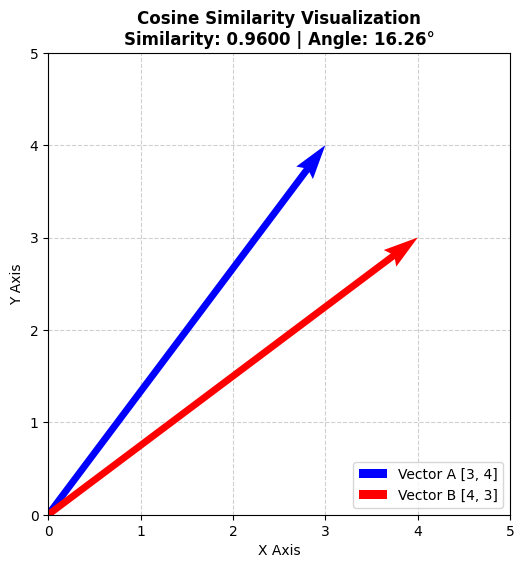

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the vectors
A = np.array([3, 4])
B = np.array([4, 3])

# 2. Calculate the Math (Dot product and Magnitudes)
dot_product = np.dot(A, B)
magnitude_A = np.linalg.norm(A)
magnitude_B = np.linalg.norm(B)

# Calculate Cosine Similarity
cosine_similarity = dot_product / (magnitude_A * magnitude_B)

# Calculate the angle in degrees for visualization
angle_rad = np.arccos(np.clip(cosine_similarity, -1.0, 1.0))
angle_deg = np.degrees(angle_rad)

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot Vector A (Blue)
ax.quiver(0, 0, A[0], A[1], angles='xy', scale_units='xy', scale=1,
          color='blue', width=0.015, label=f'Vector A {A.tolist()}')

# Plot Vector B (Red)
ax.quiver(0, 0, B[0], B[1], angles='xy', scale_units='xy', scale=1,
          color='red', width=0.015, label=f'Vector B {B.tolist()}')

# 4. Format the Graph
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_aspect('equal') # Ensures the grid is perfectly square so angles are visually accurate
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

# Add Labels and Title
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_title(f'Cosine Similarity Visualization\nSimilarity: {cosine_similarity:.4f} | Angle: {angle_deg:.2f}°', fontweight='bold')

# Add legend
ax.legend(loc='lower right')

# Display the plot
plt.show()

### 1. Understanding the Diagram

The image visualizes two data points (represented as vectors/arrows) on a standard 2D grid:

* **Vector A (Blue):** Stops at coordinates `[3, 4]`. Think of this as going 3 steps right and 4 steps up.
* **Vector B (Red):** Stops at coordinates `[4, 3]`. Think of this as going 4 steps right and 3 steps up.

Because these two lines are pointing in nearly the exact same direction, the physical gap (the angle) between them is very small (**16.26°**). Cosine similarity measures this angle. A smaller angle means higher similarity, which is why the diagram shows a very high similarity score of **0.9600** (close to a perfect 1.0).

---

### 2. The Cosine Similarity Formula

The math behind the score in your diagram relies on this formula:

$$\text{Cosine Similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{||\mathbf{A}|| \times ||\mathbf{B}||}$$

Here is what each part of that equation actually does:

* **The Numerator ($\mathbf{A} \cdot \mathbf{B}$):** This is the **Dot Product**. It multiplies the matching coordinates of both vectors and adds them together (e.g., $3 \times 4 + 4 \times 3$). It measures how much the two vectors push in the same direction combined.
* **The Denominator ($||\mathbf{A}|| \times ||\mathbf{B}||$):** This represents the **Magnitudes** (lengths) of both arrows multiplied together.
* **The Division:** By dividing the dot product by the lengths of the vectors, the formula essentially "erases" how long the arrows are. This normalizes the data so the final calculation is *only* grading the angle ($\theta$) between them.

---

### 3. What Happens If You Change the Values?

If you change the coordinates of Vector A or Vector B, the arrows will point in different directions. The length of the arrows won't change the score, but **the angle between them will**.

Cosine Similarity always results in a number strictly between **-1 and 1**. Here is a table showing what happens as the angle between the vectors changes:

| Angle Between Vectors | Cosine Similarity Score | Visual Representation | What it Means in Practice (e.g., Document Search) |
| --- | --- | --- | --- |
| **0°** | **1.0** | Arrows completely overlap. | **Perfect Match:** The items share the exact same proportions/topics. |
| **Small Angle** (e.g., 16°) | **Between 0 and 1** (e.g., 0.96) | Arrows point in roughly the same direction. | **Highly Similar:** Like comparing a document about "Space Exploration" to one about "NASA Missions". |
| **90°** | **0.0** | Arrows are perfectly perpendicular (an "L" shape). | **Unrelated:** No overlapping features. Like comparing a document about "Space" to a recipe for "Pancakes". |
| **180°** | **-1.0** | Arrows point in the exact opposite directions. | **Perfect Opposites:** In standard text analysis, scores rarely go below 0 because word counts are positive, but in sentiment analysis, this represents total disagreement. |